# Fuyuki Kobayashi
# MSCS 634
# Lab 4: Regression Analysis with the Diabetes Dataset

### Purpose

The purpose of this lab is to apply regression models using the Diabetes Dataset. 

I compare simple linear regression, multiple regression, polynomial regression, Ridge regression, and Lasso regression.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## Step 1: Load and Prepare the Dataset

In [19]:
# Load the Diabetes dataset and convert it to pandas objects
diabetes = load_diabetes()

X = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
y = pd.Series(diabetes.target, name="target")

X.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641


In [20]:
# Display feature names, dataset shape, and target summary
print("Feature names:")
print(diabetes.feature_names)

print("\nDataset shape:")
print(X.shape)

print("\nTarget summary:")
print(y.describe())

Feature names:
['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']

Dataset shape:
(442, 10)

Target summary:
count    442.000000
mean     152.133484
std       77.093005
min       25.000000
25%       87.000000
50%      140.500000
75%      211.500000
max      346.000000
Name: target, dtype: float64


In [21]:
# Check whether the dataset contains missing values
print("Missing values in features:")
print(X.isnull().sum())

print("\nMissing values in target:")
print(y.isnull().sum())

Missing values in features:
age    0
sex    0
bmi    0
bp     0
s1     0
s2     0
s3     0
s4     0
s5     0
s6     0
dtype: int64

Missing values in target:
0


## Step 2: Simple Linear Regression
I use one feature (bmi) to predict the target.

In [ ]:
# Use one feature (bmi) for simple linear regression
X_simple = X[["bmi"]]

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_simple, y, test_size=0.2, random_state=42
)

# Train the simple linear regression model and make predictions
simple_model = LinearRegression()
simple_model.fit(X_train_s, y_train_s)

y_pred_simple = simple_model.predict(X_test_s)

In [ ]:
# Calculate evaluation metrics for simple linear regression
mae_simple = mean_absolute_error(y_test_s, y_pred_simple)
mse_simple = mean_squared_error(y_test_s, y_pred_simple)
rmse_simple = np.sqrt(mse_simple)
r2_simple = r2_score(y_test_s, y_pred_simple)

print("Simple Linear Regression")
print("MAE:", mae_simple)
print("MSE:", mse_simple)
print("RMSE:", rmse_simple)
print("R2:", r2_simple)

Simple Linear Regression
MAE: 52.25997644534553
MSE: 4061.8259284949268
RMSE: 63.73245584860925
R2: 0.23335039815872138


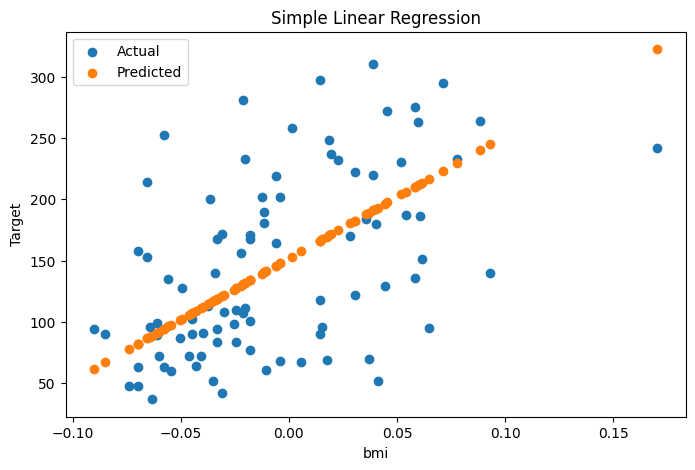

In [ ]:
# Plot actual and predicted values for simple linear regression
plt.figure(figsize=(8,5))
plt.scatter(X_test_s, y_test_s, label="Actual")
plt.scatter(X_test_s, y_pred_simple, label="Predicted")
plt.xlabel("bmi")
plt.ylabel("Target")
plt.title("Simple Linear Regression")
plt.legend()
plt.show()

The model shows limited performance because it uses only one feature.

## Step 3: Multiple Regression
I use all features to predict the target.

In [ ]:
# Split the full dataset for multiple regression
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X, y, test_size=0.2, random_state=42
)

multiple_model = LinearRegression()
multiple_model.fit(X_train_m, y_train_m)

# Train the multiple regression model and make predictions
y_pred_multiple = multiple_model.predict(X_test_m)

In [ ]:
# Calculate evaluation metrics for multiple regression
mae_multiple = mean_absolute_error(y_test_m, y_pred_multiple)
mse_multiple = mean_squared_error(y_test_m, y_pred_multiple)
rmse_multiple = np.sqrt(mse_multiple)
r2_multiple = r2_score(y_test_m, y_pred_multiple)

print("Multiple Regression")
print("MAE:", mae_multiple)
print("MSE:", mse_multiple)
print("RMSE:", rmse_multiple)
print("R2:", r2_multiple)

Multiple Regression
MAE: 42.794094679599944
MSE: 2900.1936284934823
RMSE: 53.853445836765935
R2: 0.45260276297191926


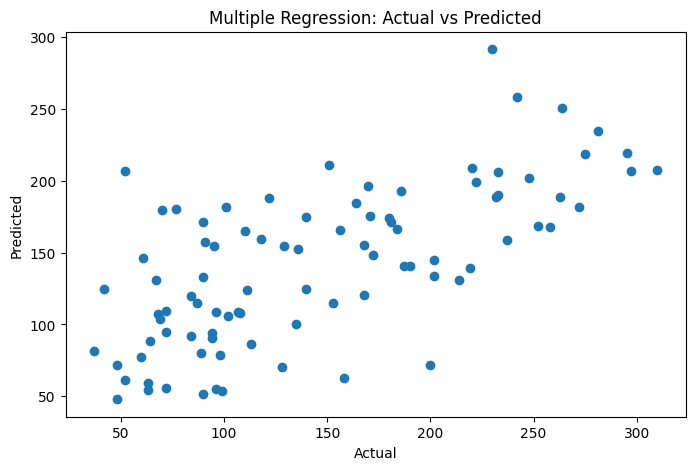

In [ ]:
# Plot actual versus predicted values for multiple regression
plt.figure(figsize=(8,5))
plt.scatter(y_test_m, y_pred_multiple)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Multiple Regression: Actual vs Predicted")
plt.show()

Using multiple features improves prediction accuracy compared to simple regression.

## Step 4: Polynomial Regression
I use the bmi feature again and compare different polynomial degrees.

In [ ]:
# Train polynomial regression models with different degrees
degrees = [2, 3, 5]
poly_results = []

for d in degrees:
    poly_model = make_pipeline(PolynomialFeatures(degree=d), LinearRegression())
    poly_model.fit(X_train_s, y_train_s)
    y_pred_poly = poly_model.predict(X_test_s)

    mae = mean_absolute_error(y_test_s, y_pred_poly)
    mse = mean_squared_error(y_test_s, y_pred_poly)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test_s, y_pred_poly)

    poly_results.append([d, mae, mse, rmse, r2])

poly_df = pd.DataFrame(poly_results, columns=["degree", "MAE", "MSE", "RMSE", "R2"])
poly_df

,degree,MAE,MSE,RMSE,R2
0,2,52.383912,4085.025481,63.914204,0.228972
1,3,52.181400,4064.443384,63.752987,0.232856
2,5,51.884611,4085.845567,63.920619,0.228817


### Interpretation
Polynomial regression did not improve performance. This may indicate overfitting or that the dataset does not contain strong nonlinear relationships.

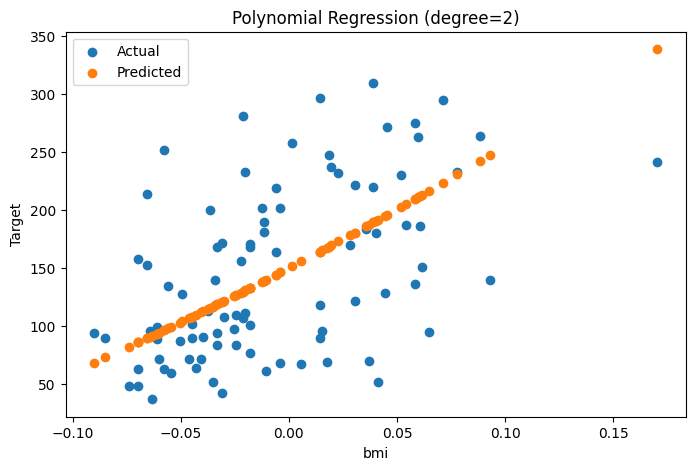

In [ ]:
# Visualize the polynomial regression results using the selected degree
best_degree = 2

poly_model = make_pipeline(PolynomialFeatures(degree=best_degree), LinearRegression())
poly_model.fit(X_train_s, y_train_s)
y_pred_poly_best = poly_model.predict(X_test_s)

plt.figure(figsize=(8,5))
plt.scatter(X_test_s, y_test_s, label="Actual")
plt.scatter(X_test_s, y_pred_poly_best, label="Predicted")
plt.xlabel("bmi")
plt.ylabel("Target")
plt.title(f"Polynomial Regression (degree={best_degree})")
plt.legend()
plt.show()

Increasing the degree does not improve performance and may lead to overfitting.

## Step 5: Ridge and Lasso Regression
I compare Ridge and Lasso using a few alpha values.

A low degree may underfit the data, while a high degree may overfit and reduce test performance.

In [ ]:
# Train Ridge and Lasso models with different alpha values
alpha_values = [0.01, 0.1, 1.0]

ridge_results = []
lasso_results = []

for a in alpha_values:
    ridge_model = Ridge(alpha=a)
    ridge_model.fit(X_train_m, y_train_m)
    y_pred_ridge = ridge_model.predict(X_test_m)

    ridge_results.append([
        a,
        mean_absolute_error(y_test_m, y_pred_ridge),
        mean_squared_error(y_test_m, y_pred_ridge),
        np.sqrt(mean_squared_error(y_test_m, y_pred_ridge)),
        r2_score(y_test_m, y_pred_ridge)
    ])

    lasso_model = Lasso(alpha=a, max_iter=10000)
    lasso_model.fit(X_train_m, y_train_m)
    y_pred_lasso = lasso_model.predict(X_test_m)

    lasso_results.append([
        a,
        mean_absolute_error(y_test_m, y_pred_lasso),
        mean_squared_error(y_test_m, y_pred_lasso),
        np.sqrt(mean_squared_error(y_test_m, y_pred_lasso)),
        r2_score(y_test_m, y_pred_lasso)
    ])

In [ ]:
# Display the evaluation results for Ridge and Lasso regression
ridge_df = pd.DataFrame(ridge_results, columns=["alpha", "MAE", "MSE", "RMSE", "R2"])
lasso_df = pd.DataFrame(lasso_results, columns=["alpha", "MAE", "MSE", "RMSE", "R2"])

print("Ridge Results")
print(ridge_df)

print("\nLasso Results")
print(lasso_df)

Ridge Results
   alpha        MAE          MSE       RMSE        R2
0   0.01  42.836888  2882.290180  53.686965  0.455982
1   0.10  42.996932  2856.486888  53.446112  0.460852
2   1.00  46.138858  3077.415939  55.474462  0.419153

Lasso Results
   alpha        MAE          MSE       RMSE        R2
0   0.01  42.831847  2878.559386  53.652208  0.456686
1   0.10  42.854428  2798.193485  52.897954  0.471855
2   1.00  49.730328  3403.575722  58.340172  0.357592


### Interpretation
Lasso achieved the highest R², but the improvement over Ridge is very small. This suggests that both regularization methods perform similarly on this dataset.

Lasso slightly outperformed Ridge, likely because it performs feature selection by shrinking less important coefficients to zero.

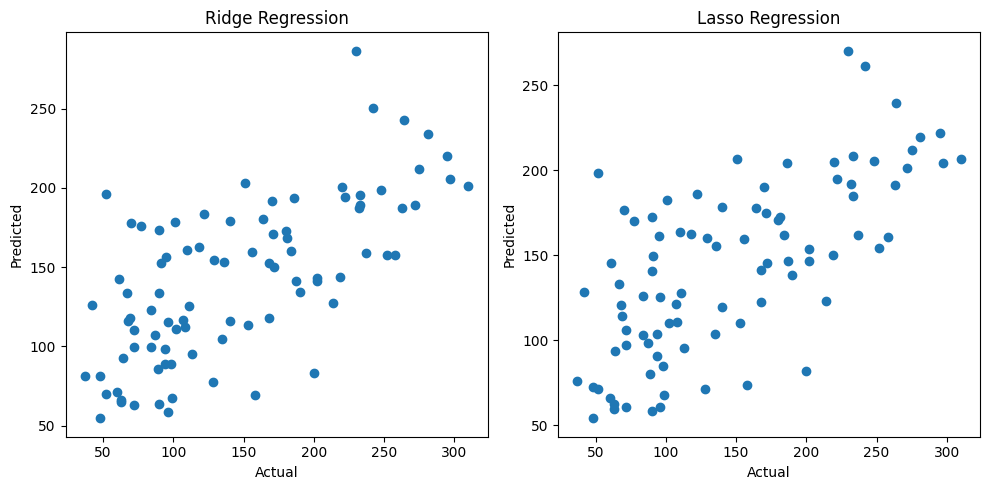

In [ ]:
# Compare actual and predicted values for Ridge and Lasso regression
ridge_model = Ridge(alpha=0.1)
ridge_model.fit(X_train_m, y_train_m)
y_pred_ridge_best = ridge_model.predict(X_test_m)

lasso_model = Lasso(alpha=0.1, max_iter=10000)
lasso_model.fit(X_train_m, y_train_m)
y_pred_lasso_best = lasso_model.predict(X_test_m)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.scatter(y_test_m, y_pred_ridge_best)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Ridge Regression")

plt.subplot(1,2,2)
plt.scatter(y_test_m, y_pred_lasso_best)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Lasso Regression")

plt.tight_layout()
plt.show()

In [ ]:
# Create a summary table to compare all regression models
best_poly_row = poly_df.loc[poly_df["R2"].idxmax()]

summary = pd.DataFrame([
    ["Simple Linear", mae_simple, mse_simple, rmse_simple, r2_simple],
    ["Multiple Regression", mae_multiple, mse_multiple, rmse_multiple, r2_multiple],
    [f"Polynomial (degree={int(best_poly_row['degree'])})", best_poly_row["MAE"], best_poly_row["MSE"], best_poly_row["RMSE"], best_poly_row["R2"]],
    ["Ridge (alpha=0.1)", ridge_df[ridge_df["alpha"] == 0.1]["MAE"].values[0],
                          ridge_df[ridge_df["alpha"] == 0.1]["MSE"].values[0],
                          ridge_df[ridge_df["alpha"] == 0.1]["RMSE"].values[0],
                          ridge_df[ridge_df["alpha"] == 0.1]["R2"].values[0]],
    ["Lasso (alpha=0.1)", lasso_df[lasso_df["alpha"] == 0.1]["MAE"].values[0],
                          lasso_df[lasso_df["alpha"] == 0.1]["MSE"].values[0],
                          lasso_df[lasso_df["alpha"] == 0.1]["RMSE"].values[0],
                          lasso_df[lasso_df["alpha"] == 0.1]["R2"].values[0]]
], columns=["Model", "MAE", "MSE", "RMSE", "R2"])

summary

,Model,MAE,MSE,RMSE,R2
0,Simple Linear,52.259976,4061.825928,63.732456,0.233350
1,Multiple Regression,42.794095,2900.193628,53.853446,0.452603
2,Polynomial (degree=3),52.181400,4064.443384,63.752987,0.232856
3,Ridge (alpha=0.1),42.996932,2856.486888,53.446112,0.460852
4,Lasso (alpha=0.1),42.854428,2798.193485,52.897954,0.471855


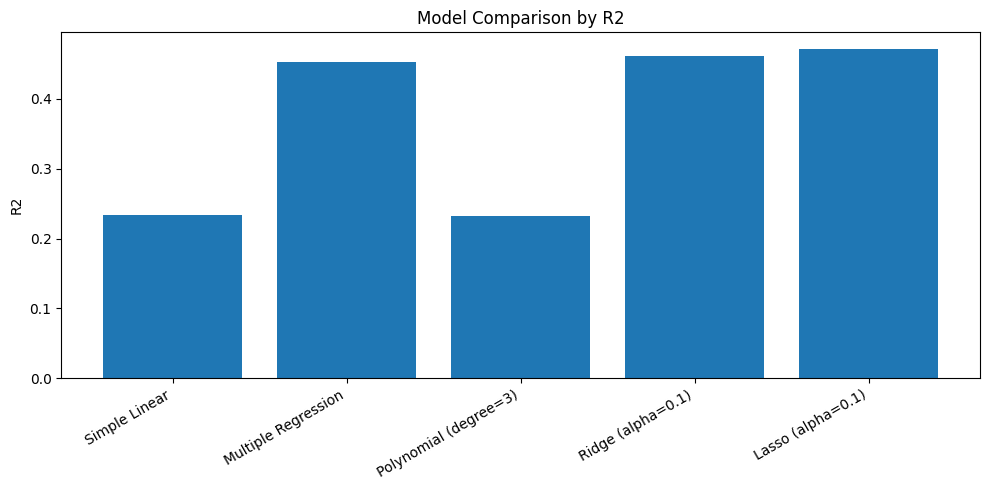

In [ ]:
# Plot R² values to compare overall model performance
plt.figure(figsize=(10,5))
plt.bar(summary["Model"], summary["R2"])
plt.xticks(rotation=30, ha="right")
plt.ylabel("R2")
plt.title("Model Comparison by R2")
plt.tight_layout()
plt.show()

Regularization helps control model complexity. Moderate alpha values perform better.

## Step 6: Model Comparison and Analysis

The simple linear regression model had the lowest performance, with an R² of about 0.23. This is expected because it uses only one feature.

The multiple regression model performed better, with an R² of about 0.45. Using all features improved prediction accuracy.

Polynomial regression did not improve performance compared to simple linear regression. Even with higher degrees, the R² stayed around 0.23. This shows that increasing model complexity does not always improve results.

Ridge and Lasso regression gave similar or slightly better results than multiple regression. The best result was from Lasso with alpha = 0.10, which achieved an R² of about 0.47.

When the alpha value became too large (alpha = 1.0), both Ridge and Lasso performance decreased. This shows that too much regularization can reduce model accuracy.

Overall, regularized models (especially Lasso) performed the best in this lab.

## Conclusion

In this lab, I applied different regression models to the Diabetes Dataset.

Simple linear regression had limited performance because it used only one feature. Multiple regression improved the results by using all features.

Polynomial regression did not improve performance in this case. Increasing the degree did not lead to better predictions.

Ridge and Lasso regression helped control model complexity. The best performance was achieved by Lasso with a moderate alpha value.

This lab showed that using more features and applying proper regularization can improve model performance.